this will be for music property analysis

# Separating daily_genre column into separate rows

First I'll separate the multiple values in the `preferred_genre_daily` column from our interim data with cleaned labels and demographics:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load the demographic-cleaned version (before genre indicators were added)
survey_demo_df = pd.read_csv('../data/interim/survey_cleaned_demographic.csv')

# check dataframe:
survey_demo_df['preferred_genre_daily'].unique()

array(['Electronic, Pop', 'Hip Hop & R&B', 'Hip Hop & R&B, Pop',
       'Metal/ Rock, Hip Hop & R&B, Pop',
       'Hip Hop & R&B, Electronic, indie',
       'Hip Hop & R&B, Indie, Alternative ',
       'Metal/ Rock, Jazz/ Classical, Pop, Indie',
       'Metal/ Rock, Jazz/ Classical, Pop, indie',
       'Metal/ Rock, Electronic, Pop',
       'Hip Hop & R&B, Jazz/ Classical, Pop',
       'Metal/ Rock, Hip Hop & R&B, Jazz/ Classical, Pop, kpop, krnb, ',
       'Metal/ Rock, Hip Hop & R&B, Jazz/ Classical, Pop',
       'Metal/ Rock, Hip Hop & R&B, Electronic, Pop',
       'Hip Hop & R&B, Electronic, Pop',
       'Country / Folk, Pop, Regional Mexican Music ',
       'Hip Hop & R&B, Pop, Rap',
       'Metal/ Rock, Hip Hop & R&B, Country / Folk, Jazz/ Classical, Electronic, Pop',
       'Electronic, Pop, Alternative, hyperpop',
       'Hip Hop & R&B, Pop, kpop',
       'Metal/ Rock, Jazz/ Classical, Electronic, Pop',
       'Hip Hop & R&B, Pop, A little of everything ',
       'Hip Hop & R&B

In [5]:
# let's explode the preferred_daily_genre column into **one genre per row** so you can see and edit the values more easily:

daily_genre_exploded_df = (
    survey_demo_df #our original cleaned demographic dataframe

    # this splits each cell's comma-separated string (genre) into a list
    .assign(preferred_genre_daily=lambda x: x['preferred_genre_daily'].str.split(','))

    # explode will turn each list element into its own row and duplicate alll other columns
    .explode('preferred_genre_daily')

    #this will strip whitespace and lowercase all the genre values to make them more consistent
    .assign(preferred_genre_daily=lambda x: x['preferred_genre_daily'].str.strip().str.lower())

    # this will drop any empty string rows that came from trailing commas (safety measure!)
    .query("preferred_genre_daily != ''")

    #this resets the index since explode can create duplicate index values --> "drop= TRUE" means is doesn't add the old index as a column
    .reset_index(drop=True)
)

# see every unique raw value
print(daily_genre_exploded_df['preferred_genre_daily'].value_counts())

daily_genre_exploded_df.head()

preferred_genre_daily
pop                       32
hip hop & r&b             31
electronic                14
metal/ rock               11
jazz/ classical            9
indie                      4
alternative                3
kpop                       2
country / folk             2
krnb                       1
regional mexican music     1
rap                        1
hyperpop                   1
a little of everything     1
latin hip-hop              1
Name: count, dtype: int64


,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober,race_ethnicity
0,1,2/25/2026 12:10:43,man,electronic,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
1,1,2/25/2026 12:10:43,man,pop,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
2,2,2/25/2026 12:19:46,woman,hip hop & r&b,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
3,3,2/25/2026 12:21:41,woman,hip hop & r&b,4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,dancing and ambience,"FOMO, friends are going and to take a break fr...",hispanic,american,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ...",latine/hispanic
4,3,2/25/2026 12:21:41,woman,pop,4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,dancing and ambience,"FOMO, friends are going and to take a break fr...",hispanic,american,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ...",latine/hispanic


In [6]:
### now we'll expaned the the combined categories like Hip Hop & R&B inot separate genres first!

# first, this dictionary defines the mapping of combined genres to their individual components:
expand_map = {
    'hip hop & r&b':   ['hip hop', 'r&b'],
    'jazz/ classical': ['jazz', 'classical'],
    'krnb':            ['r&b'],  #KRNB is Korean R&B by the way
}

# this function checks if a genre is in expand_map and returns its expanded list
# if it's NOT in the expand_map, it just wraps the orginal value in a list so explode works consistently
def expand_genres(genre):
    return expand_map.get(genre, [genre])

# and now we'll apply the expand step to the datafram
daily_genre_exploded_df = (
    daily_genre_exploded_df # the datafram with exploded genres

    # apply expand_genres to every cell in the column `preferred_genre_daily`
    .assign(preferred_genre_daily=lambda x: x['preferred_genre_daily'].apply(expand_genres))

    # explode again to turn the new lists into rows
    .explode('preferred_genre_daily')

    # reset index again
    .reset_index(drop=True)
)

# check the unique values again to see the expanded genres:
print(daily_genre_exploded_df['preferred_genre_daily'].value_counts())

daily_genre_exploded_df.head()

preferred_genre_daily
pop                       32
r&b                       32
hip hop                   31
electronic                14
metal/ rock               11
jazz                       9
classical                  9
indie                      4
alternative                3
kpop                       2
country / folk             2
regional mexican music     1
rap                        1
hyperpop                   1
a little of everything     1
latin hip-hop              1
Name: count, dtype: int64


,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober,race_ethnicity
0,1,2/25/2026 12:10:43,man,electronic,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
1,1,2/25/2026 12:10:43,man,pop,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
2,2,2/25/2026 12:19:46,woman,hip hop,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
3,2,2/25/2026 12:19:46,woman,r&b,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
4,3,2/25/2026 12:21:41,woman,hip hop,4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,dancing and ambience,"FOMO, friends are going and to take a break fr...",hispanic,american,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ...",latine/hispanic


## Standardize genres

Ok now we can standardize the genres to these main 12:
- Hip-hop
- R&B
- Jazz
- Classical
- Pop
- Electronic
- Metal/Rock
- Indie
- Latin Music
- Country/Folk
- Rap
- Alternative

In [7]:
# now we'll map the raw genre values to more standardized categories for analysis. This is a bit subjective but I tried to group similar genres together while keeping distinct ones separate
genre_daily_map = {
    'hip hop':                'hip hop',   # <-- was 'hip-hop': 'hip-hop', needs to match expand_map output
    'r&b':                    'r&b',
    'jazz':                   'jazz',
    'classical':              'classical',
    'rap':                    'rap',
    'pop':                    'pop',
    'hyperpop':               'pop',
    'electronic':             'electronic',
    'metal/ rock':            'metal/rock',
    'indie':                  'indie',
    'alternative':            'alternative',
    'latin hip-hop':          'latin music',
    'regional mexican music': 'latin music',
    'country / folk':         'country/folk',
    'kpop':                   'pop',
    # krnb is already handled by expand_map → 'r&b', so no need for it here
    # 'a little of everything' excluded → gets dropped
}

daily_genre_exploded_df['preferred_genre_daily'] = daily_genre_exploded_df['preferred_genre_daily'].map(genre_daily_map)
daily_genre_exploded_df = daily_genre_exploded_df.dropna(subset=['preferred_genre_daily']).reset_index(drop=True)

print(daily_genre_exploded_df['preferred_genre_daily'].value_counts())

preferred_genre_daily
pop             35
r&b             32
hip hop         31
electronic      14
metal/rock      11
jazz             9
classical        9
indie            4
alternative      3
country/folk     2
latin music      2
rap              1
Name: count, dtype: int64


In [8]:
# let's look at the dataframe again after standardizing the genres:

daily_genre_exploded_df.head()

,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober,race_ethnicity
0,1,2/25/2026 12:10:43,man,electronic,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
1,1,2/25/2026 12:10:43,man,pop,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
2,2,2/25/2026 12:19:46,woman,hip hop,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
3,2,2/25/2026 12:19:46,woman,r&b,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
4,3,2/25/2026 12:21:41,woman,hip hop,4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,dancing and ambience,"FOMO, friends are going and to take a break fr...",hispanic,american,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ...",latine/hispanic


In [9]:
# let's save this version with the standardized, exploded genres as a csv:

daily_genre_exploded_df.to_csv('../data/interim/daily_genre_exploded_df.csv', index=False)

# Analyzing daily genres

In [10]:
daily_genre_exploded_df['preferred_genre_daily'].value_counts()

preferred_genre_daily
pop             35
r&b             32
hip hop         31
electronic      14
metal/rock      11
jazz             9
classical        9
indie            4
alternative      3
country/folk     2
latin music      2
rap              1
Name: count, dtype: int64

C:\Users\aranz\AppData\Local\Temp\ipykernel_40876\3481209254.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_genre_counts.index, y=daily_genre_counts.values, palette='viridis')


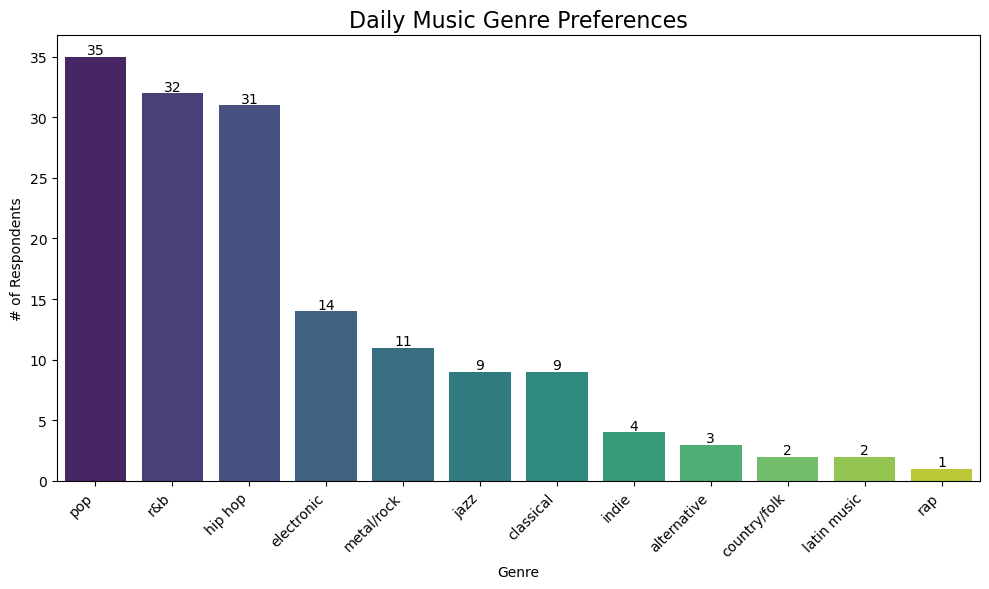

<Figure size 640x480 with 0 Axes>

In [11]:
daily_genre_counts = daily_genre_exploded_df['preferred_genre_daily'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=daily_genre_counts.index, y=daily_genre_counts.values, palette='viridis')
plt.title('Daily Music Genre Preferences', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('# of Respondents')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns the labels nicely under the bars

# add count labels on top of each bar
for i, v in enumerate(daily_genre_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.savefig('../figures/daily_genre_preferences.png', dpi=150, bbox_inches='tight')
plt.show()

plt.savefig('../figures/daily_genre_preferences.png', dpi=150, bbox_inches='tight')

In [12]:
daily_genre_exploded_df

,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober,race_ethnicity
0,1,2/25/2026 12:10:43,man,electronic,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
1,1,2/25/2026 12:10:43,man,pop,3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
2,2,2/25/2026 12:19:46,woman,hip hop,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
3,2,2/25/2026 12:19:46,woman,r&b,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
4,3,2/25/2026 12:21:41,woman,hip hop,4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,dancing and ambience,"FOMO, friends are going and to take a break fr...",hispanic,american,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ...",latine/hispanic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,39,3/4/2026 19:43:04,woman,pop,3,22,"Electronic, Pop","The Way I Are - Timbaland, Diva - Beyonce, Dis...",I've liked how everyone is down to speak to ea...,I usually don't like it if the music is too l...,...,I try to include crowd favourites that I know ...,"To socialise, dance, have fun, and relax.",kazakh,kazakh,3,4,NaN,"NOKIA - Drake, Five More Hours - Deorro, Beaut...",Yes I have. I thought it was fun,asian
149,40,3/4/2026 22:20:37,woman,hip hop,3,21,"Hip Hop & R&B, Jazz/ Classical","Ah We Ah-Ahmed Mounib, After The Beep- Faye Wo...",An excuse to dance,If the music is too loud or if you can’t dance...,...,To dance and feel groovy,To dance,kurdish,american,5,2,Yes- derinm13@icloud.com,"Snap My Finger -Kaytranada ft. Pink Panthress,...","Yes, I party/dance hard",asian
150,40,3/4/2026 22:20:37,woman,r&b,3,21,"Hip Hop & R&B, Jazz/ Classical","Ah We Ah-Ahmed Mounib, After The Beep- Faye Wo...",An excuse to dance,If the music is too loud or if you can’t dance...,...,To dance and feel groovy,To dance,kurdish,american,5,2,Yes- derinm13@icloud.com,"Snap My Finger -Kaytranada ft. Pink Panthress,...","Yes, I party/dance hard",asian
151,40,3/4/2026 22:20:37,woman,jazz,3,21,"Hip Hop & R&B, Jazz/ Classical","Ah We Ah-Ahmed Mounib, After The Beep- Faye Wo...",An excuse to dance,If the mu

# Clean/ Tidy `preferred_genre_parties`

Now we'll essentially do the same for this column as we did for the daily genre preferences

In [13]:
# first let's look at the unique values in the preferred_genre_parties column to see what we're working with:

daily_genre_exploded_df['preferred_genre_parties'].unique()

array(['Hip Hop & R&B, Pop', 'Hip Hop & R&B, Electronic, Pop',
       'Electronic, Pop', 'Hip Hop & R&B, Electronic, Pop, edm', 'Pop',
       'Metal/ Rock, Jazz/ Classical, Pop, indie',
       'Metal/ Rock, Electronic, Pop', 'Hip Hop & R&B',
       'Hip Hop & R&B, Jazz/ Classical, Pop',
       'Metal/ Rock, Hip Hop & R&B, Electronic, Pop',
       'Country / Folk, Pop, Bachata/Salsa/Regional Mexican Music',
       'Metal/ Rock, Hip Hop & R&B, Jazz/ Classical', 'Pop, House, EDM',
       'Pop, kpop', 'Pop, Reggaeton', 'Hip Hop & R&B, Jazz/ Classical'],
      dtype=object)

In [14]:
# step 1 — explode into one genre per row
party_genre_exploded_df = (
    daily_genre_exploded_df
    .assign(preferred_genre_parties=lambda x: x['preferred_genre_parties'].str.split(','))
    .explode('preferred_genre_parties')
    .assign(preferred_genre_parties=lambda x: x['preferred_genre_parties'].str.strip().str.lower())
    .query("preferred_genre_parties != ''")
    .reset_index(drop=True)
)

print(party_genre_exploded_df['preferred_genre_parties'].value_counts())

party_genre_exploded_df.head()

preferred_genre_parties
pop                                     138
hip hop & r&b                           102
electronic                               72
jazz/ classical                          17
metal/ rock                              16
edm                                       6
indie                                     5
reggaeton                                 5
kpop                                      4
house                                     4
country / folk                            3
bachata/salsa/regional mexican music      3
Name: count, dtype: int64


,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober,race_ethnicity
0,1,2/25/2026 12:10:43,man,electronic,3,23,hip hop & r&b,"Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
1,1,2/25/2026 12:10:43,man,electronic,3,23,pop,"Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
2,1,2/25/2026 12:10:43,man,pop,3,23,hip hop & r&b,"Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
3,1,2/25/2026 12:10:43,man,pop,3,23,pop,"Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
4,2,2/25/2026 12:19:46,woman,hip hop,2,20,hip hop & r&b,"Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian


In [15]:
# start fresh from the original cleaned demographic dataframe
party_genre_exploded_df = (
    survey_demo_df
    .assign(preferred_genre_parties=lambda x: x['preferred_genre_parties'].str.split(','))
    .explode('preferred_genre_parties')
    .assign(preferred_genre_parties=lambda x: x['preferred_genre_parties'].str.strip().str.lower())
    .query("preferred_genre_parties != ''")
    .reset_index(drop=True)
)

# expand combined categories
expand_map_party = {
    'hip hop & r&b':   ['hip hop', 'r&b'],
    'jazz/ classical': ['jazz', 'classical'],
}

def expand_genres_party(genre):
    return expand_map_party.get(genre, [genre])

party_genre_exploded_df = (
    party_genre_exploded_df
    .assign(preferred_genre_parties=lambda x: x['preferred_genre_parties'].apply(expand_genres_party))
    .explode('preferred_genre_parties')
    .reset_index(drop=True)
)

# standardize
genre_party_map = {
    'hip hop':                              'hip hop',
    'r&b':                                  'r&b',
    'jazz':                                 'jazz',
    'classical':                            'classical',
    'pop':                                  'pop',
    'electronic':                           'electronic',
    'edm':                                  'electronic',
    'house':                                'electronic',
    'metal/ rock':                          'metal/rock',
    'indie':                                'indie',
    'bachata/salsa/regional mexican music': 'latin music',
    'reggaeton':                            'latin music',
    'country / folk':                       'country/folk',
    'kpop':                                 'pop',
}

party_genre_exploded_df['preferred_genre_parties'] = party_genre_exploded_df['preferred_genre_parties'].map(genre_party_map)
party_genre_exploded_df = party_genre_exploded_df.dropna(subset=['preferred_genre_parties']).reset_index(drop=True)

print(party_genre_exploded_df['preferred_genre_parties'].value_counts())

preferred_genre_parties
pop             36
hip hop         27
r&b             27
electronic      21
metal/rock       4
jazz             4
classical        4
latin music      2
indie            1
country/folk     1
Name: count, dtype: int64


C:\Users\aranz\AppData\Local\Temp\ipykernel_40876\3100193751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_genre_counts.index, y=party_genre_counts.values, palette='viridis')


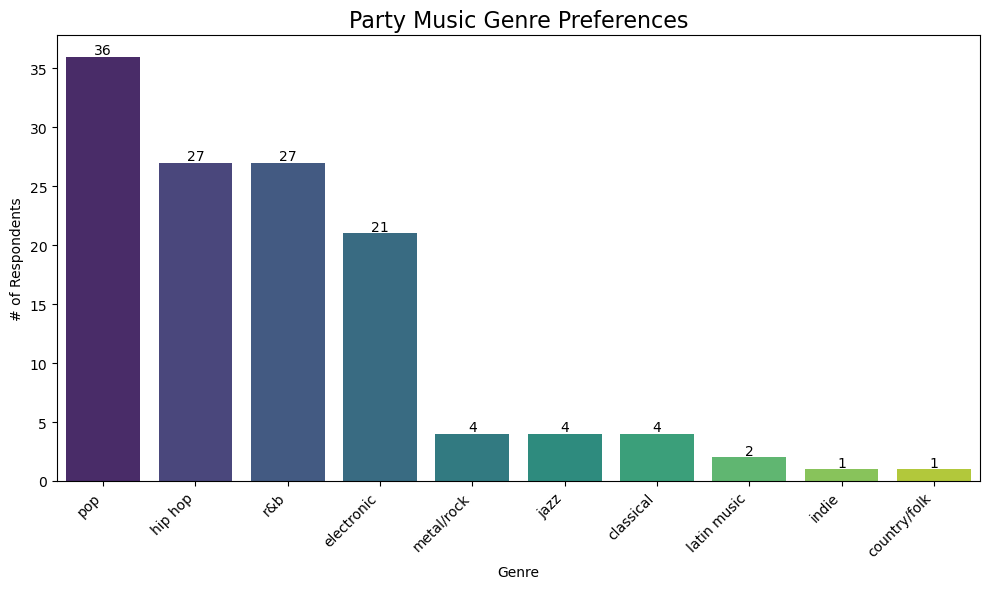

<Figure size 640x480 with 0 Axes>

In [16]:
# and now let's plot the party preferred genres:

party_genre_counts = party_genre_exploded_df['preferred_genre_parties'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_genre_counts.index, y=party_genre_counts.values, palette='viridis')
plt.title('Party Music Genre Preferences', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('# of Respondents')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns the labels nicely under the bars

# add count labels on top of each bar
for i, v in enumerate(party_genre_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.savefig('../figures/party_genre_preferences.png', dpi=150, bbox_inches='tight')
plt.show()

plt.savefig('../figures/party_genre_preferences.png', dpi=150, bbox_inches='tight')

In [17]:
# let's add this as a csv file as well

party_genre_exploded_df.to_csv('../data/interim/party_genre_exploded_df.csv', index=False)

# Loud Music vs No Music
looking at the likelihood scales

In [18]:
clean_genre_set = pd.read_csv('../data/interim/party_genre_exploded_df.csv')

clean_genre_set.head()

,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober,race_ethnicity
0,1,2/25/2026 12:10:43,man,"Electronic, Pop",3,23,hip hop,"Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
1,1,2/25/2026 12:10:43,man,"Electronic, Pop",3,23,r&b,"Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
2,1,2/25/2026 12:10:43,man,"Electronic, Pop",3,23,pop,"Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
3,2,2/25/2026 12:19:46,woman,Hip Hop & R&B,2,20,hip hop,"Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
4,2,2/25/2026 12:19:46,woman,Hip Hop & R&B,2,20,r&b,"Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian


Now let's see see and plot the responses for the `likelihood_conversation_no_music_score`and `likelihood_conversation_loud_music_score`.

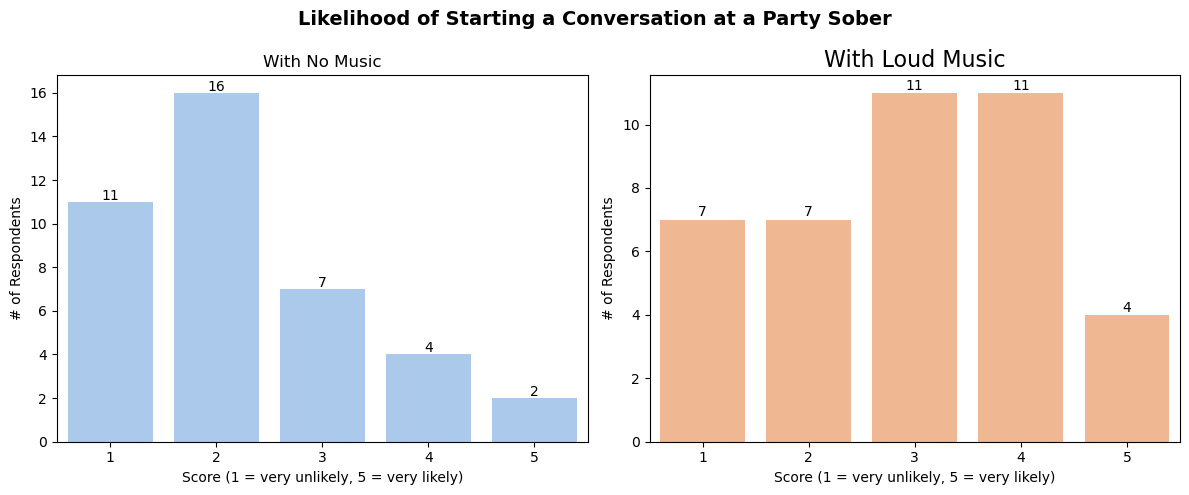

No music — mean: 2.25 | std: 1.13
Loud music — mean: 2.95 | std: 1.26


<Figure size 640x480 with 0 Axes>

In [19]:
# deduplicate to one row per participant before counting scores
clean_genre_deduped = clean_genre_set.drop_duplicates(subset='participant_id')

# get value counts for both columns
no_music_counts = clean_genre_deduped['likelihood_conversation_no_music_score'].value_counts().sort_index()
loud_music_counts = clean_genre_deduped['likelihood_conversation_loud_music_score'].value_counts().sort_index()

# make sure all scores 1-5 are represented even if count is 0
all_scores = pd.Series(0, index=range(1, 6))
no_music_counts = all_scores.add(no_music_counts, fill_value=0).astype(int)
loud_music_counts = all_scores.add(loud_music_counts, fill_value=0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Likelihood of Starting a Conversation at a Party Sober', fontsize=14, fontweight='bold')

# no music
sns.barplot(x=no_music_counts.index, y=no_music_counts.values, ax=axes[0], color=sns.color_palette('pastel')[0])
axes[0].set_title('With No Music')
axes[0].set_xlabel('Score (1 = very unlikely, 5 = very likely)')
axes[0].set_ylabel('# of Respondents')
for i, v in enumerate(no_music_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center')

# loud music
sns.barplot(x=loud_music_counts.index, y=loud_music_counts.values, ax=axes[1], color=sns.color_palette('pastel')[1])
axes[1].set_title('With Loud Music', fontsize=16)
axes[1].set_xlabel('Score (1 = very unlikely, 5 = very likely)')
axes[1].set_ylabel('# of Respondents')
for i, v in enumerate(loud_music_counts.values):
    axes[1].text(i, v + 0.1, str(v), ha='center')

plt.tight_layout()
plt.savefig('../figures/conversation_likelihood.png', dpi=150, bbox_inches='tight')
plt.show()
plt.savefig('../figures/loud_vs_no_music_conversation_likelihood.png', dpi=150, bbox_inches='tight')

# print summary stats for both
print("No music — mean:", round(clean_genre_deduped['likelihood_conversation_no_music_score'].mean(), 2),
      "| std:", round(clean_genre_deduped['likelihood_conversation_no_music_score'].std(), 2))
print("Loud music — mean:", round(clean_genre_deduped['likelihood_conversation_loud_music_score'].mean(), 2),
      "| std:", round(clean_genre_deduped['likelihood_conversation_loud_music_score'].std(), 2))

# Song BPM Datasets

Now we'll load in the datasets on musical properties from the song choices in the survey of pre-party and when hsoting a party. We'll also upload the dataset of the songs BPM for the naturalistic observations.

In [20]:
# let's load in the datasets:

# survey songs
preparty_songs_df = pd.read_csv('../data/raw/Team Directory - Pre-Party Songs (2).csv')
hosting_songs_df = pd.read_csv('../data/raw/Team Directory - Hosting Party Songs (2).csv')

# natural observations songs
natural_songs_df = pd.read_csv('../data/raw/Team Directory - Naturalistic Obs. Songs (2).csv')


## Natural Obs. Song Genres

In [21]:
# let's look each df
natural_songs_df.columns

Index(['Naturalistic Obsercation Songs', 'Artist', 'BPM', 'No Artist Listed',
       'Genre (r)', 'Unnamed: 5', 'Key', 'Loudness (dB)', 'Rhythm'],
      dtype='object')

In [22]:
natural_songs_df['Genre (r)'].unique()

array(['pop', 'R&B ', 'Soul', 'Trap ', 'House ', 'pop ', 'Rock', 'indie',
       'reggaeton', 'Regional Mexicano', 'reggaeton ', 'Latin', nan,
       'Hip Hop'], dtype=object)

In [23]:
# strip whitespace and lowercase first
natural_songs_df['Genre (r)'] = natural_songs_df['Genre (r)'].str.strip().str.lower()

# now check unique values
natural_songs_df['Genre (r)'].value_counts()

Genre (r)
reggaeton            8
latin                4
pop                  4
soul                 3
r&b                  2
rock                 2
regional mexicano    2
indie                1
house                1
trap                 1
hip hop              1
Name: count, dtype: int64

In [24]:
# now we'll map genres to our 12 standard ones from before:
genre_natural_map = {
    'pop':                'pop',
    'r&b':                'r&b',
    'soul':               'r&b',         # soul → r&b (closest in your 12)
    'hip hop':            'hip hop',
    'trap':               'hip hop',     # trap → hip hop
    'rock':               'metal/rock',
    'indie':              'indie',
    'house':              'electronic',  # house → electronic
    'reggaeton':          'latin music',
    'regional mexicano':  'latin music',
    'latin':              'latin music',
}

natural_songs_df['genre_clean'] = natural_songs_df['Genre (r)'].map(genre_natural_map)

# drop the NaN (1 missing value)
natural_songs_df = natural_songs_df.dropna(subset=['genre_clean']).reset_index(drop=True)

print(natural_songs_df['genre_clean'].value_counts())

genre_clean
latin music    14
r&b             5
pop             4
hip hop         2
metal/rock      2
electronic      1
indie           1
Name: count, dtype: int64


C:\Users\aranz\AppData\Local\Temp\ipykernel_40876\470542824.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=natural_genre_counts.index, y=natural_genre_counts.values, palette='viridis')


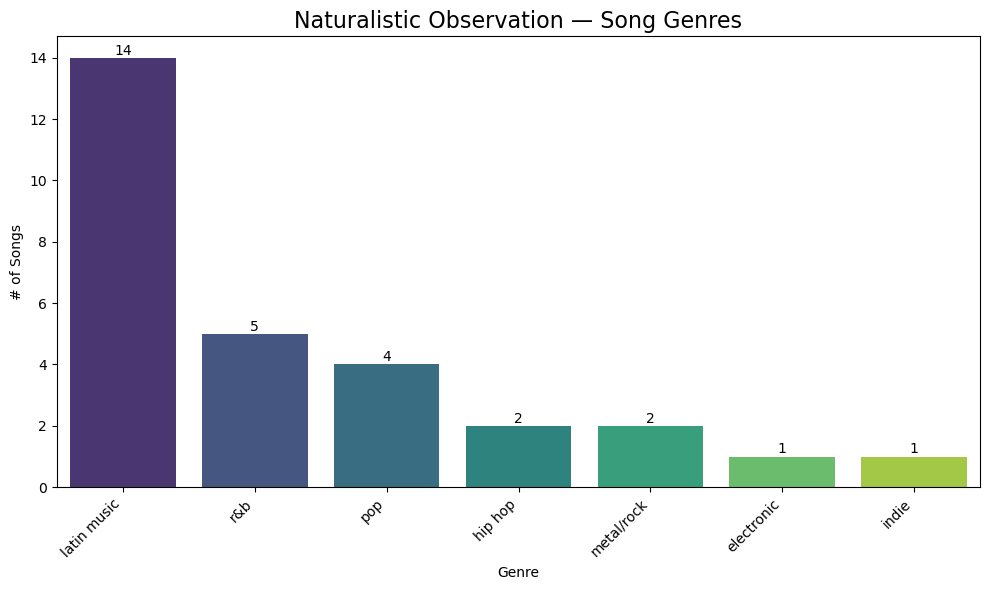

In [25]:
natural_genre_counts = natural_songs_df['genre_clean'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=natural_genre_counts.index, y=natural_genre_counts.values, palette='viridis')
plt.title('Naturalistic Observation — Song Genres', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('# of Songs')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(natural_genre_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center')

plt.tight_layout()
plt.savefig('../figures/natural_obs_genres.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
#i'm also gonna save this genre clean version into interim folder

natural_songs_df.to_csv('../data/interim/natural_songs_genre_clean_df.csv', index=False)

## Pre-party Song Genres

In [27]:
# first we'll look at the unqiue values in the genre column to see what we're working with:

# strip and lowercase first so we can see the true unique values
preparty_songs_df['Genre (r)'] = preparty_songs_df['Genre (r)'].str.strip().str.lower()

print(preparty_songs_df['Genre (r)'].value_counts())
print(preparty_songs_df.shape)

Genre (r)
pop                  72
r&b                  18
hip-hop               9
reggaeton             5
house                 5
rap                   5
rock                  3
alternative           3
trap                  3
dance/electronic      3
indie                 2
edm                   2
banda                 2
electronic            2
tencho-merengue       1
electro               1
alternative metal     1
musical theater       1
bolero                1
dembow                1
boom bap              1
bachata               1
tribal                1
breakbeat             1
corridos              1
dubstep               1
electroclash          1
regional mexicano     1
Name: count, dtype: int64
(165, 8)


In [28]:
preparty_songs_df.isnull().sum()

Pre Party Songs       9
Artist               11
BPM                  11
No Artist Listed    158
Genre (r)            17
Key                 157
Loudness (dB)        13
Rhythm               17
dtype: int64

In [29]:
# let's drop rows after row 160
preparty_songs_df = preparty_songs_df.iloc[:159]

print(preparty_songs_df.isnull().sum())
preparty_songs_df.shape

Pre Party Songs       3
Artist               10
BPM                  10
No Artist Listed    152
Genre (r)            11
Key                 156
Loudness (dB)        12
Rhythm               11
dtype: int64


(159, 8)

In [30]:
# now let's standardize and map em

genre_preparty_map = {
    # keep as is
    'pop':               'pop',
    'r&b':               'r&b',
    'hip-hop':           'hip hop',
    'rock':              'metal/rock',
    'indie':             'indie',
    'alternative':       'alternative',

    # hip hop family
    'rap':               'hip hop',
    'trap':              'hip hop',
    'boom bap':          'hip hop',

    # electronic family
    'house':             'electronic',
    'edm':               'electronic',
    'dance/electronic':  'electronic',
    'electronic':        'electronic',
    'electro':           'electronic',
    'electroclash':      'electronic',
    'breakbeat':         'electronic',
    'dubstep':           'electronic',

    # latin music family
    'reggaeton':         'latin music',
    'bachata':           'latin music',
    'dembow':            'latin music',
    'banda':             'latin music',
    'corridos':          'latin music',
    'regional mexicano': 'latin music',
    'tencho-merengue':   'latin music',
    'tribal':            'latin music',
    'bolero':            'latin music',

    # alternative family
    'alternative metal': 'alternative',

    # outlier, did its second genre
    'musical theater':   'pop',
}

preparty_songs_df['genre_clean'] = preparty_songs_df['Genre (r)'].map(genre_preparty_map)
preparty_songs_df = preparty_songs_df.dropna(subset=['genre_clean']).reset_index(drop=True)

print(preparty_songs_df['genre_clean'].value_counts())

genre_clean
pop            73
hip hop        18
r&b            18
electronic     16
latin music    14
alternative     4
metal/rock      3
indie           2
Name: count, dtype: int64


C:\Users\aranz\AppData\Local\Temp\ipykernel_40876\3408997003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=preparty_genre_counts.index, y=preparty_genre_counts.values, palette='viridis')


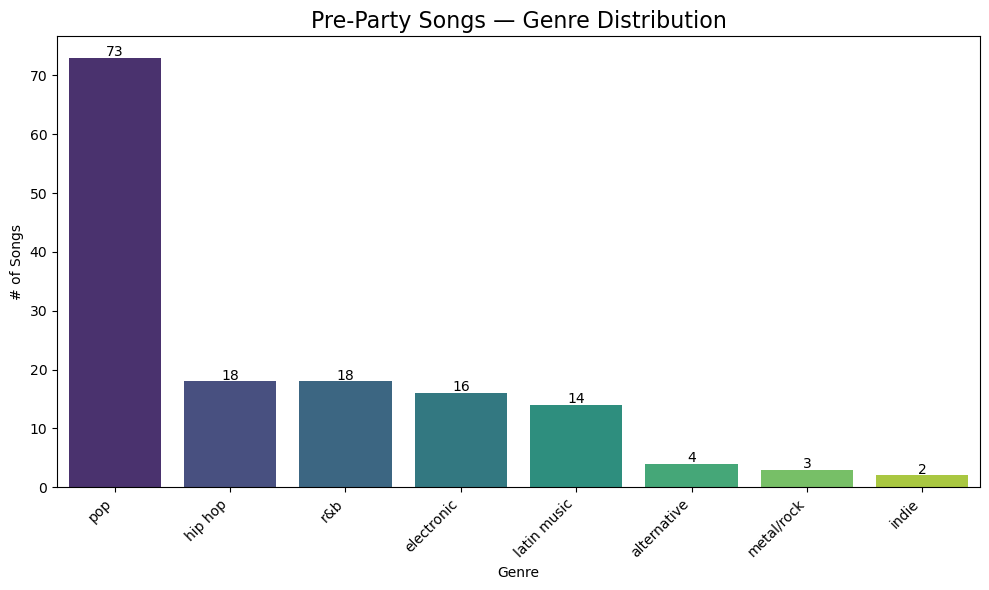

In [31]:
# plot the genre counts for preparty songs!
preparty_genre_counts = preparty_songs_df['genre_clean'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=preparty_genre_counts.index, y=preparty_genre_counts.values, palette='viridis')
plt.title('Pre-Party Songs — Genre Distribution', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('# of Songs')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(preparty_genre_counts.values):
    plt.text(i, v + 0.3, str(v), ha='center')

plt.tight_layout()
plt.savefig('../figures/preparty_genre_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## Hosting Song Genres

In [32]:
# first we'll look at the unqiue values in the genre column to see what we're working with:

# strip and lowercase first so we can see the true unique values
hosting_songs_df['Genre (r)'] = hosting_songs_df['Genre (r)'].str.strip().str.lower()

print(hosting_songs_df['Genre (r)'].value_counts())
print(hosting_songs_df.shape)

Genre (r)
pop                  54
reggaeton            15
rap                   9
house                 9
r&b                   7
hip-hop               6
edm                   5
cumbia                5
rock                  4
regional mexicano     3
jazz                  3
indie                 3
indian indie          1
tribal guarachero     1
brazilian funk        1
trap                  1
soul                  1
Name: count, dtype: int64
(137, 8)


In [33]:
print(hosting_songs_df.isnull().sum())
hosting_songs_df.tail(10)

Hosting Party Songs      6
Artist                   4
BPM                      5
No Artist Listed       134
Genre (r)                9
Key                     59
Loudness (dB)            4
Rhythm                  64
dtype: int64


,Hosting Party Songs,Artist,BPM,No Artist Listed,Genre (r),Key,Loudness (dB),Rhythm
127,Witchy,Kaytranda,110.00000,NaN,pop,NaN,-8.000000,NaN
128,Atrevete te te,Calle 13,88.00000,NaN,reggaeton,NaN,-6.000000,NaN
129,When I come around,Dom Kennedy,98.00000,NaN,hip-hop,NaN,-7.000000,NaN
130,Anything,Amr Diab,78.00000,NaN,pop,NaN,-6.000000,NaN
131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,NaN,Median:,126.00000,NaN,NaN,Median:,-6.000000,NaN
133,NaN,Max:,200.00000,NaN,NaN,Max:,-2.000000,NaN
134,NaN,Min:,64.00000,NaN,NaN,Min:,-46.000000,NaN
135,NaN,Mode:,128.00000,NaN,NaN,Mode:,-6.000000,NaN
136,NaN,Average/mean:,122.19685,NaN,NaN,Average/mean:,-6.632812,NaN


In [36]:
hosting_songs_df = hosting_songs_df.iloc[:131]
print(hosting_songs_df.shape)
print(hosting_songs_df.isnull().sum())


(131, 8)
Hosting Party Songs      0
Artist                   3
BPM                      4
No Artist Listed       128
Genre (r)                3
Key                     58
Loudness (dB)            3
Rhythm                  58
dtype: int64


In [37]:
# ok now let's map the hosting songs genres to the standard 12 categories as well:

genre_hosting_map = {
    # keep as is
    'pop':               'pop',
    'r&b':               'r&b',
    'hip-hop':           'hip hop',
    'jazz':              'jazz',
    'indie':             'indie',
    'rock':              'metal/rock',

    # hip hop family
    'rap':               'hip hop',
    'trap':              'hip hop',

    # electronic family
    'house':             'electronic',
    'edm':               'electronic',

    # latin music family
    'reggaeton':         'latin music',
    'cumbia':            'latin music',
    'regional mexicano': 'latin music',
    'tribal guarachero': 'latin music',
    'brazilian funk':    'latin music',

    # r&b family
    'soul':              'r&b',

    # indie family
    'indian indie':      'indie',
}

hosting_songs_df['genre_clean'] = hosting_songs_df['Genre (r)'].map(genre_hosting_map)
hosting_songs_df = hosting_songs_df.dropna(subset=['genre_clean']).reset_index(drop=True)

print(hosting_songs_df['genre_clean'].value_counts())
print("total songs after cleaning:", hosting_songs_df['genre_clean'].value_counts().sum())

genre_clean
pop            54
latin music    25
hip hop        16
electronic     14
r&b             8
metal/rock      4
indie           4
jazz            3
Name: count, dtype: int64
total songs after cleaning: 128


C:\Users\aranz\AppData\Local\Temp\ipykernel_40876\29550931.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hosting_genre_counts.index, y=hosting_genre_counts.values, palette='viridis')


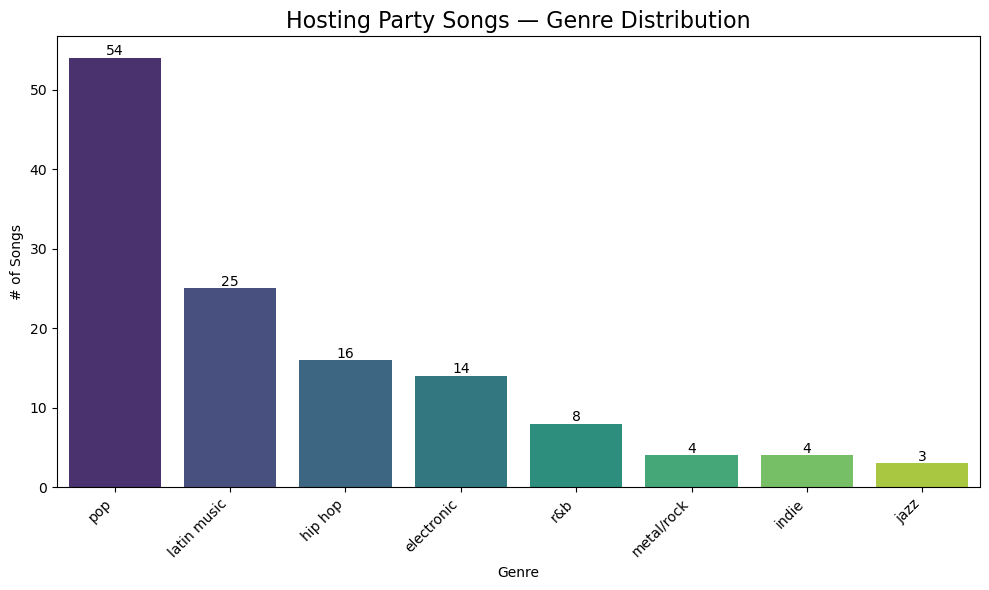

In [40]:
# now plotting hosting party genre counts:
hosting_genre_counts = hosting_songs_df['genre_clean'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=hosting_genre_counts.index, y=hosting_genre_counts.values, palette='viridis')
plt.title('Hosting Party Songs — Genre Distribution', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('# of Songs')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(hosting_genre_counts.values):
    plt.text(i, v + 0.3, str(v), ha='center')

plt.tight_layout()
plt.savefig('../figures/hosting_genre_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# save cleaned versions to interim folder
preparty_songs_df.to_csv('../data/interim/preparty_songs_genre_cleaned.csv', index=False)
hosting_songs_df.to_csv('../data/interim/hosting_songs_genre_cleaned.csv', index=False)